In [109]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
import re
from config.secret import GITHUB_TOKEN


def request_data(target_issues=10_000, max_pages=500):
    params = {"per_page": 100, "state": "all"}
    url = "https://api.github.com/repos/godotengine/godot/issues"

    all_rows = []
    fetched_pages = 0

    while url and fetched_pages < max_pages and len(all_rows) < target_issues:
        fetched_pages += 1
        print(f"Processing page {fetched_pages} | collected={len(all_rows)}")

        r = requests.get(
            url,
            params=params,
            headers={"Authorization": f"Bearer {GITHUB_TOKEN}"},
            timeout=30,
        )

        if not r.ok:
            try:
                err = r.json()
            except ValueError:
                err = r.text
            raise RuntimeError(f"Request failed {r.status_code}: {err}")

        data = r.json()
        if not isinstance(data, list):
            raise RuntimeError(f"Expected list from /issues, got {type(data)}: {data}")

        # keep only actual issues (drop PRs immediately)
        for item in data:
            if "pull_request" not in item:
                all_rows.append(item)
                if len(all_rows) >= target_issues:
                    break

        url = r.links.get("next", {}).get("url")

    return pd.DataFrame(all_rows)


df = request_data(target_issues=20_000)
print("Fetched issues:", len(df))
df

Processing page 1 | collected=0
Processing page 2 | collected=52
Processing page 3 | collected=108
Processing page 4 | collected=153
Processing page 5 | collected=196
Processing page 6 | collected=236
Processing page 7 | collected=281
Processing page 8 | collected=337
Processing page 9 | collected=400
Processing page 10 | collected=443
Processing page 11 | collected=484
Processing page 12 | collected=529
Processing page 13 | collected=589
Processing page 14 | collected=625
Processing page 15 | collected=666
Processing page 16 | collected=706
Processing page 17 | collected=746
Processing page 18 | collected=784
Processing page 19 | collected=817
Processing page 20 | collected=869
Processing page 21 | collected=907
Processing page 22 | collected=953
Processing page 23 | collected=1003
Processing page 24 | collected=1040
Processing page 25 | collected=1078
Processing page 26 | collected=1125
Processing page 27 | collected=1169
Processing page 28 | collected=1222
Processing page 29 | colle

,url,repository_url,labels_url,comments_url,events_url,html_url,id,node_id,number,title,...,type,active_lock_reason,sub_issues_summary,issue_dependencies_summary,body,closed_by,reactions,timeline_url,performed_via_github_app,state_reason
0,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://github.com/godotengine/godot/issues/11...,3927825342,I_kwDOAO6SJc7qHdu-,116178,V-Sync Not defaulting Project Setting in the s...,...,None,NaN,"{'total': 0, 'completed': 0, 'percent_complete...","{'blocked_by': 0, 'total_blocked_by': 0, 'bloc...","### Tested versions\n\n- Tested: Godot 4.6, 4....",None,{'url': 'https://api.github.com/repos/godoteng...,https://api.github.com/repos/godotengine/godot...,None,NaN
1,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://github.com/godotengine/godot/issues/11...,3927751640,I_kwDOAO6SJc7qHLvY,116177,Mouse not warp when `editors/3d/navigation/nav...,...,None,NaN,"{'total': 0, 'completed': 0, 'percent_complete...","{'blocked_by': 0, 'total_blocked_by': 0, 'bloc...",### Tested versions\n\nreproducible in 4.5.1.s...,None,{'url': 'https://api.github.com/repos/godoteng...,https://api.github.com/repos/godotengine/godot...,None,NaN
2,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://github.com/godotengine/godot/issues/11...,3927751341,I_kwDOAO6SJc7qHLqt,116176,`FileAccess` & `DirAccess` can create invalid ...,...,None,NaN,"{'total': 0, 'completed': 0, 'percent_complete...","{'blocked_by': 0, 'total_blocked_by': 0, 'bloc...",### Tested versions\n\n- Reproducible in: v4.6...,None,{'url': 'https://api.github.com/repos/godoteng...,https://api.github.com/repos/godotengine/godot...,None,NaN
3,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://github.com/godotengine/godot/issues/11...,3927705872,I_kwDOAO6SJc7qHAkQ,116174,Bug: Localized titles do not work on Android (...,...,None,NaN,"{'total': 0, 'completed': 0, 'percent_complete...","{'blocked_by': 0, 'total_blocked_by': 0, 'bloc...",### Tested versions\n\nI tested this example o...,None,{'url': 'https://api.github.com/repos/godoteng...,https://api.github.com/repos/godotengine/godot...,None,NaN
4,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://github.com/godotengine/godot/issues/11...,3927651384,I_kwDOAO6SJc7qGzQ4,116173,Node with 2D/3D child node in Packed Scene is ...,...,None,NaN,"{'total': 0, 'completed': 0, 'percent_complete...","{'blocked_by': 0, 'total_blocked_by': 0, 'bloc...",### Tested versions\n\nreproducible in 4.5.1.s...,None,{'url': 'https://api.github.com/repos/godoteng...,https://api.github.com/repos/godotengine/godot...,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://api.github.com/repos/godotengine/godot...,https://github.com/godotengine/godot/issues/75396,1642389854,I_kwDOAO6SJc5h5OFe,7539

In [110]:
KEEP_COLS = ["id", "title", "body", "created_at", "labels"]
df = df[KEEP_COLS].copy()
df

,id,title,body,created_at,labels
0,3927825342,V-Sync Not defaulting Project Setting in the s...,"### Tested versions\n\n- Tested: Godot 4.6, 4....",2026-02-11T17:47:48Z,[]
1,3927751640,Mouse not warp when `editors/3d/navigation/nav...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11T17:30:49Z,[]
2,3927751341,`FileAccess` & `DirAccess` can create invalid ...,### Tested versions\n\n- Reproducible in: v4.6...,2026-02-11T17:30:44Z,[]
3,3927705872,Bug: Localized titles do not work on Android (...,### Tested versions\n\nI tested this example o...,2026-02-11T17:19:28Z,[]
4,3927651384,Node with 2D/3D child node in Packed Scene is ...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11T17:06:49Z,"[{'id': 73330066, 'node_id': 'MDU6TGFiZWw3MzMz..."
...,...,...,...,...,...
19995,1642389854,Inconsitent peer id type in C#,### Godot version\r\n\r\n4.0.1 stable mono win...,2023-03-27T16:05:35Z,"[{'id': 73330064, 'node_id': 'MDU6TGFiZWw3MzMz..."
19996,1642373346,i cannot seem to loop imported animations when...,### Godot version\r\n\r\nGodot 4.0.1 stable\r\...,2023-03-27T15:56:51Z,"[{'id': 279096997, 'node_id': 'MDU6TGFiZWwyNzk..."
19997,1642259537,Typed arrays won't accept node references with $,### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27T14:54:15Z,"[{'id': 73330064, 'node_id': 'MDU6TGFiZWw3MzMz..."
19998,1642179038,"Static function ""duplicate"" on custom classes ...",### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27T14:15:49Z,"[{'id': 279097162, 'node_id': 'MDU6TGFiZWwyNzk..."


In [111]:
LABELS_TO_DROP = {
    "archived", "confirmed", "for pr meeting", "good first issue",
    "needs testing", "needs work", "spam", "salvageable", "tracker",
    "cherrypick:3.5", "cherrypick:3.6", "cherrypick:3.x",
    "cherrypick:4.2", "cherrypick:4.3", "cherrypick:4.4",
    "cherrypick:4.5", "cherrypick:4.6",
}

def labels_to_names(labels):
    """
    Accepts:
      - list[dict] from GitHub API OR
      - list[str] if already processed
    Returns:
      - list[str] label names (filtered)
    """
    if not isinstance(labels, list):
        return []
    out = []
    for x in labels:
        if isinstance(x, dict):
            name = x.get("name")
        elif isinstance(x, str):
            name = x
        else:
            continue

        if name and name not in LABELS_TO_DROP:
            out.append(name)
    return out

df["labels"] = df["labels"].apply(labels_to_names)


In [112]:
df

,id,title,body,created_at,labels
0,3927825342,V-Sync Not defaulting Project Setting in the s...,"### Tested versions\n\n- Tested: Godot 4.6, 4....",2026-02-11T17:47:48Z,[]
1,3927751640,Mouse not warp when `editors/3d/navigation/nav...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11T17:30:49Z,[]
2,3927751341,`FileAccess` & `DirAccess` can create invalid ...,### Tested versions\n\n- Reproducible in: v4.6...,2026-02-11T17:30:44Z,[]
3,3927705872,Bug: Localized titles do not work on Android (...,### Tested versions\n\nI tested this example o...,2026-02-11T17:19:28Z,[]
4,3927651384,Node with 2D/3D child node in Packed Scene is ...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11T17:06:49Z,"[enhancement, discussion, documentation, topic..."
...,...,...,...,...,...
19995,1642389854,Inconsitent peer id type in C#,### Godot version\r\n\r\n4.0.1 stable mono win...,2023-03-27T16:05:35Z,"[bug, topic:network, topic:dotnet]"
19996,1642373346,i cannot seem to loop imported animations when...,### Godot version\r\n\r\nGodot 4.0.1 stable\r\...,2023-03-27T15:56:51Z,[]
19997,1642259537,Typed arrays won't accept node references with $,### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27T14:54:15Z,"[bug, topic:gdscript]"
19998,1642179038,"Static function ""duplicate"" on custom classes ...",### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27T14:15:49Z,"[discussion, topic:gdscript]"


In [114]:
MIN_SUPPORT = 200
N = 20

labels_exploded = df["labels"].explode()
topic_counts = (
    labels_exploded[
        labels_exploded.notna()
        & labels_exploded.astype(str).str.startswith("topic:")
    ]
    .value_counts()
)

eligible = topic_counts[topic_counts >= MIN_SUPPORT]
top_topic_strings = eligible.head(N).index.tolist()

print("Top topics:", len(top_topic_strings))
print(top_topic_strings[:10])

Top topics: 20
['topic:editor', 'topic:rendering', 'topic:3d', 'topic:gui', 'topic:core', 'topic:gdscript', 'topic:2d', 'topic:platforms', 'topic:animation', 'topic:input']


In [115]:
RAW_ISSUE_TYPES = {"bug", "discussion", "enhancement", "documentation"}
ISSUE_TYPE_NORMALIZE = {
    "bug": "bug",
    "discussion": "discussion",
    "enhancement": "feature_request",
    "documentation": "docs",
}
ISSUE_TYPE_PRECEDENCE = ["bug", "feature_request", "docs", "discussion"]

PLATFORM_MAP = {
    "platform:windows": "windows",
    "platform:android": "android",
    "platform:linuxbsd": "linuxbsd",
    "platform:macos": "macos",
    "platform:web": "web",
}

IMPACTS = {"crash", "usability", "regression", "performance"}
TOPIC_PREFIX = "topic:"
TOPIC_OTHER = "other"

def normalize_df_drop_labels(df: pd.DataFrame, labels_col="labels", default_issue_type=None):
    top_topics_set = set(top_topic_strings)
    precedence_rank = {name: i for i, name in enumerate(ISSUE_TYPE_PRECEDENCE)}

    def _process(labels):
        if not isinstance(labels, list):
            labels = []

        issue_candidates = set()
        platform, impact, topic = [], [], []

        seen_platform, seen_impact, seen_topic = set(), set(), set()
        needs_other = False

        for lab in labels:
            if not isinstance(lab, str):
                continue

            # issue type candidates
            if lab in RAW_ISSUE_TYPES:
                issue_candidates.add(ISSUE_TYPE_NORMALIZE[lab])

            # platform list (stripped)
            if lab in PLATFORM_MAP:
                p = PLATFORM_MAP[lab]
                if p not in seen_platform:
                    platform.append(p); seen_platform.add(p)

            # impact list
            if lab in IMPACTS:
                if lab not in seen_impact:
                    impact.append(lab); seen_impact.add(lab)

            # topic list (top only, else other)
            if lab.startswith(TOPIC_PREFIX) and len(lab) > len(TOPIC_PREFIX):
                if lab in top_topics_set:
                    t = lab[len(TOPIC_PREFIX):]
                    if t not in seen_topic:
                        topic.append(t); seen_topic.add(t)
                else:
                    needs_other = True

        if needs_other and TOPIC_OTHER not in seen_topic:
            topic.append(TOPIC_OTHER)

        # choose one issue_type by precedence
        if issue_candidates:
            issue_type = min(issue_candidates, key=lambda x: precedence_rank.get(x, float("inf")))
        else:
            issue_type = default_issue_type

        return issue_type, platform, impact, topic

    out = df.copy()
    extracted = out[labels_col].apply(
        lambda x: pd.Series(_process(x), index=["issue_type", "platform", "impact", "topic"])
    )
    out = pd.concat([out.drop(columns=[labels_col]), extracted], axis=1)
    return out

final_df = normalize_df_drop_labels(df)
final_df.head()

,id,title,body,created_at,issue_type,platform,impact,topic
0,3927825342,V-Sync Not defaulting Project Setting in the s...,"### Tested versions\n\n- Tested: Godot 4.6, 4....",2026-02-11T17:47:48Z,NaN,[],[],[]
1,3927751640,Mouse not warp when `editors/3d/navigation/nav...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11T17:30:49Z,NaN,[],[],[]
2,3927751341,`FileAccess` & `DirAccess` can create invalid ...,### Tested versions\n\n- Reproducible in: v4.6...,2026-02-11T17:30:44Z,NaN,[],[],[]
3,3927705872,Bug: Localized titles do not work on Android (...,### Tested versions\n\nI tested this example o...,2026-02-11T17:19:28Z,NaN,[],[],[]
4,3927651384,Node with 2D/3D child node in Packed Scene is ...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11T17:06:49Z,feature_request,[],[],[3d]


In [116]:
final_df["created_at"] = pd.to_datetime(final_df["created_at"], utc=True, errors="coerce")
final_df = final_df.dropna(subset=["created_at"]).reset_index(drop=True)
final_df

,id,title,body,created_at,issue_type,platform,impact,topic
0,3927825342,V-Sync Not defaulting Project Setting in the s...,"### Tested versions\n\n- Tested: Godot 4.6, 4....",2026-02-11 17:47:48+00:00,NaN,[],[],[]
1,3927751640,Mouse not warp when `editors/3d/navigation/nav...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11 17:30:49+00:00,NaN,[],[],[]
2,3927751341,`FileAccess` & `DirAccess` can create invalid ...,### Tested versions\n\n- Reproducible in: v4.6...,2026-02-11 17:30:44+00:00,NaN,[],[],[]
3,3927705872,Bug: Localized titles do not work on Android (...,### Tested versions\n\nI tested this example o...,2026-02-11 17:19:28+00:00,NaN,[],[],[]
4,3927651384,Node with 2D/3D child node in Packed Scene is ...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11 17:06:49+00:00,feature_request,[],[],[3d]
...,...,...,...,...,...,...,...,...
19995,1642389854,Inconsitent peer id type in C#,### Godot version\r\n\r\n4.0.1 stable mono win...,2023-03-27 16:05:35+00:00,bug,[],[],"[dotnet, other]"
19996,1642373346,i cannot seem to loop imported animations when...,### Godot version\r\n\r\nGodot 4.0.1 stable\r\...,2023-03-27 15:56:51+00:00,NaN,[],[],[]
19997,1642259537,Typed arrays won't accept node references with $,### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27 14:54:15+00:00,bug,[],[],[gdscript]
19998,1642179038,"Static function ""duplicate"" on custom classes ...",### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27 14:15:49+00:00,discussion,[],[],[gdscript]


In [117]:
FENCED_CODE_REMOVE = re.compile(r"```[\s\S]*?```", re.MULTILINE)
INLINE_CODE = re.compile(r"`([^`]+)`")
URLS = re.compile(r"https?://\S+")
MD_LEADERS = re.compile(r"(?m)^\s{0,3}(?:#{1,6}\s+|[-*+]\s+|>\s+)")

def clean_markdown(text, remove_code_blocks=True, keep_urls=True, url_placeholder="URL"):
    if text is None:
        return ""
    if not isinstance(text, str):
        text = str(text)

    t = text
    if remove_code_blocks:
        t = FENCED_CODE_REMOVE.sub(" ", t)

    t = INLINE_CODE.sub(r"\1", t)
    t = MD_LEADERS.sub("", t)

    if not keep_urls:
        t = URLS.sub(f" {url_placeholder} ", t)

    # IMPORTANT: collapse whitespace to ONE space (not empty)
    t = re.sub(r"\s+", " ", t).strip()
    return t

final_df["text_raw"] = final_df["title"].fillna("") + "\n\n" + final_df["body"].fillna("")
final_df["text_clean"] = final_df["text_raw"].apply(clean_markdown)

In [118]:
final_df

,id,title,body,created_at,issue_type,platform,impact,topic,text_raw,text_clean
0,3927825342,V-Sync Not defaulting Project Setting in the s...,"### Tested versions\n\n- Tested: Godot 4.6, 4....",2026-02-11 17:47:48+00:00,NaN,[],[],[],V-Sync Not defaulting Project Setting in the s...,V-Sync Not defaulting Project Setting in the s...
1,3927751640,Mouse not warp when `editors/3d/navigation/nav...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11 17:30:49+00:00,NaN,[],[],[],Mouse not warp when `editors/3d/navigation/nav...,Mouse not warp when editors/3d/navigation/navi...
2,3927751341,`FileAccess` & `DirAccess` can create invalid ...,### Tested versions\n\n- Reproducible in: v4.6...,2026-02-11 17:30:44+00:00,NaN,[],[],[],`FileAccess` & `DirAccess` can create invalid ...,FileAccess & DirAccess can create invalid file...
3,3927705872,Bug: Localized titles do not work on Android (...,### Tested versions\n\nI tested this example o...,2026-02-11 17:19:28+00:00,NaN,[],[],[],Bug: Localized titles do not work on Android (...,Bug: Localized titles do not work on Android (...
4,3927651384,Node with 2D/3D child node in Packed Scene is ...,### Tested versions\n\nreproducible in 4.5.1.s...,2026-02-11 17:06:49+00:00,feature_request,[],[],[3d],Node with 2D/3D child node in Packed Scene is ...,Node with 2D/3D child node in Packed Scene is ...
...,...,...,...,...,...,...,...,...,...,...
19995,1642389854,Inconsitent peer id type in C#,### Godot version\r\n\r\n4.0.1 stable mono win...,2023-03-27 16:05:35+00:00,bug,[],[],"[dotnet, other]",Inconsitent peer id type in C#\n\n### Godot ve...,Inconsitent peer id type in C# Godot version 4...
19996,1642373346,i cannot seem to loop imported animations when...,### Godot version\r\n\r\nGodot 4.0.1 stable\r\...,2023-03-27 15:56:51+00:00,NaN,[],[],[],i cannot seem to loop imported animations when...,i cannot seem to loop imported animations when...
19997,1642259537,Typed arrays won't accept node references with $,### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27 14:54:15+00:00,bug,[],[],[gdscript],Typed arrays won't accept node references with...,Typed arrays won't accept node references with...
19998,1642179038,"Static function ""duplicate"" on custom classes ...",### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27 14:15:49+00:00,discussion,[],[],[gdscript],"Static function ""duplicate"" on custom classes ...","Static function ""duplicate"" on custom classes ..."


In [119]:
label_vocab = {
    "issue_type": sorted(final_df["issue_type"].dropna().unique().tolist()),
    "platform": sorted({p for row in final_df["platform"] for p in row}),
    "impact": sorted({x for row in final_df["impact"] for x in row}),
    "topic": sorted({t for row in final_df["topic"] for t in row}),
}

In [120]:
final_df = final_df.sort_values("created_at").reset_index(drop=True)

n = len(final_df)
train_end = int(0.70 * n)
val_end   = int(0.80 * n)  # tune=80%, test=20%

train_df = final_df.iloc[:train_end]
val_df   = final_df.iloc[train_end:val_end]
test_df  = final_df.iloc[val_end:]

train_df.to_json("train.json", orient="records")
val_df.to_json("val.json", orient="records")
test_df.to_json("test.json", orient="records")

with open("label_vocab.json", "w") as f:
    json.dump(label_vocab, f, indent=2)

print("Wrote train.json, val.json, test.json, label_vocab.json")

C:\Users\purpa\AppData\Local\Temp\ipykernel_32968\612083864.py:11: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  train_df.to_json("train.json", orient="records")


Wrote train.json, val.json, test.json, label_vocab.json


C:\Users\purpa\AppData\Local\Temp\ipykernel_32968\612083864.py:12: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  val_df.to_json("val.json", orient="records")
C:\Users\purpa\AppData\Local\Temp\ipykernel_32968\612083864.py:13: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  test_df.to_json("test.json", orient="records")


In [ ]:
final_df

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

def barh_counts(counts: pd.Series, title: str, top_n: int = 25):
    s = counts.head(top_n).sort_values()
    plt.figure(figsize=(10, max(4, 0.35 * len(s))))
    plt.barh(s.index.astype(str), s.values)
    plt.xlabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


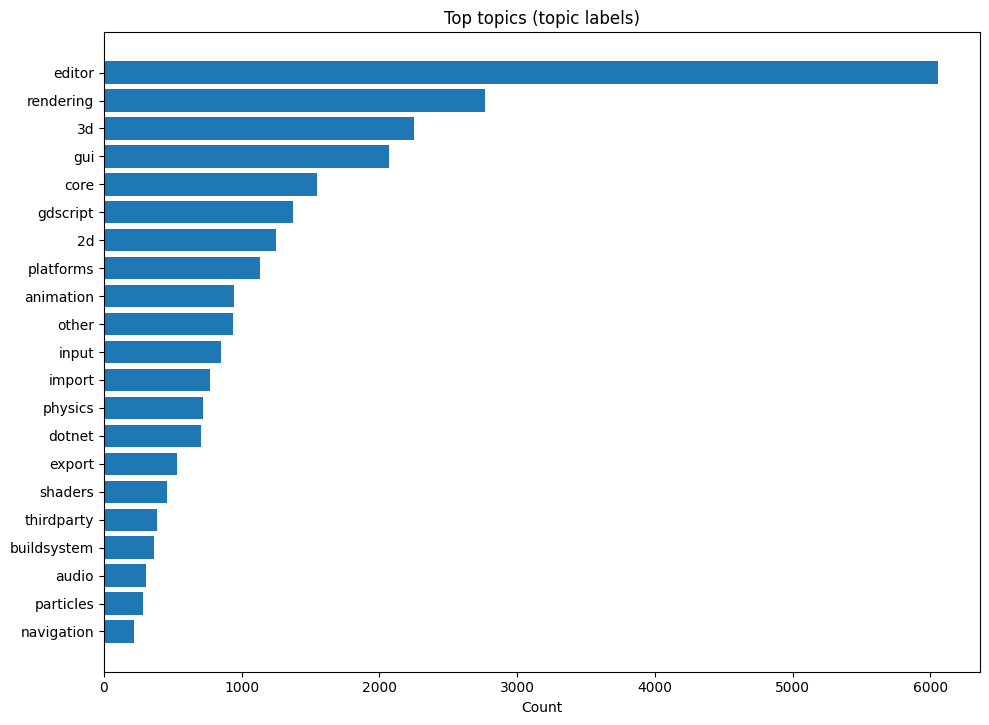

In [122]:
topic_counts = final_df["topic"].explode().dropna().value_counts()
barh_counts(topic_counts, "Top topics (topic labels)", top_n=25)


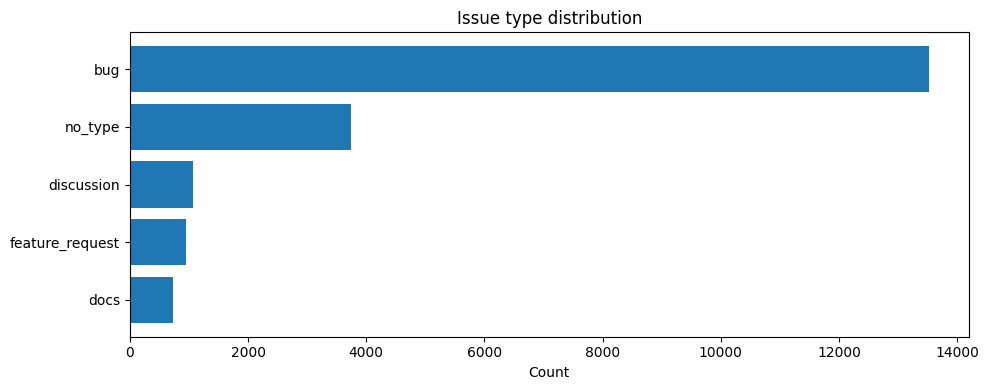

In [137]:
issue_type_counts = final_df["issue_type"].fillna("no_type").value_counts(dropna=False)
barh_counts(issue_type_counts, "Issue type distribution", top_n=20)

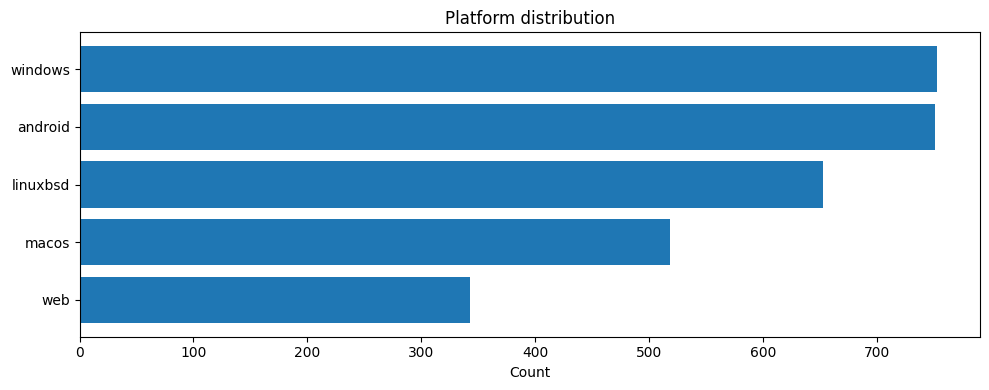

In [131]:
platform_counts = final_df["platform"].explode().dropna().value_counts()
barh_counts(platform_counts, "Platform distribution", top_n=20)


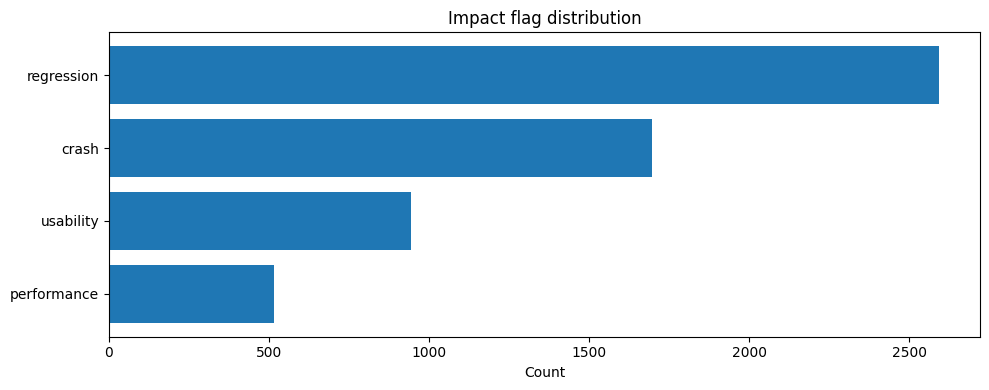

In [132]:
impact_counts = final_df["impact"].explode().dropna().value_counts()
barh_counts(impact_counts, "Impact flag distribution", top_n=20)


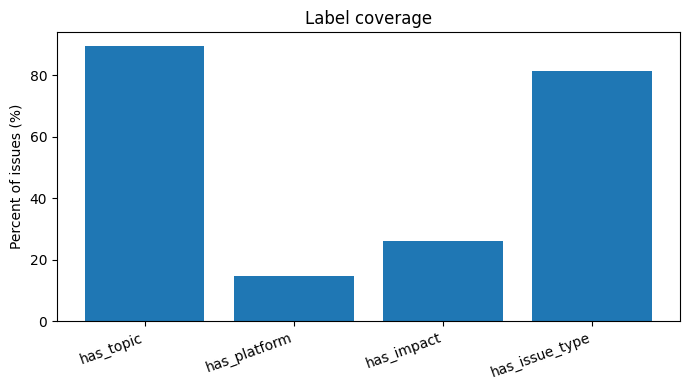

In [133]:
def has_any_list(x):
    return isinstance(x, list) and len(x) > 0

coverage = pd.Series({
    "has_topic": final_df["topic"].apply(has_any_list).mean(),
    "has_platform": final_df["platform"].apply(has_any_list).mean(),
    "has_impact": final_df["impact"].apply(has_any_list).mean(),
    "has_issue_type": final_df["issue_type"].notna().mean(),
}) * 100

plt.figure(figsize=(7,4))
plt.bar(coverage.index, coverage.values)
plt.ylabel("Percent of issues (%)")
plt.title("Label coverage")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


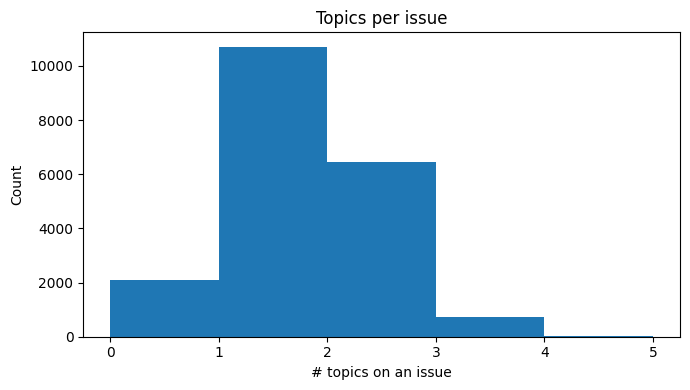

In [134]:
topic_per_issue = final_df["topic"].apply(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(7,4))
plt.hist(topic_per_issue, bins=range(0, int(topic_per_issue.max()) + 2))
plt.xlabel("# topics on an issue")
plt.ylabel("Count")
plt.title("Topics per issue")
plt.tight_layout()
plt.show()


In [135]:
other_share = final_df["topic"].apply(lambda xs: ("other" in xs) if isinstance(xs, list) else False).mean() * 100
print(f"Percent of issues containing topic='other': {other_share:.2f}%")


Percent of issues containing topic='other': 4.69%


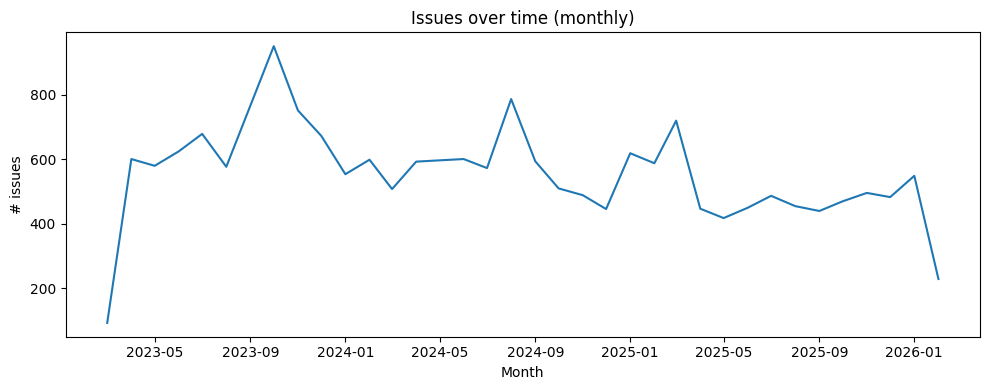

In [136]:
tmp = final_df.dropna(subset=["created_at"]).copy()
monthly = tmp.set_index("created_at").resample("MS").size()

plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.values)
plt.xlabel("Month")
plt.ylabel("# issues")
plt.title("Issues over time (monthly)")
plt.tight_layout()
plt.show()
